# Problem Description

Supermarket chains in Ecuador operate across dozens of cities and product categories, making demand forecasting a critical operational challenge. Accurate sales predictions help optimize inventory, reduce waste, and improve customer satisfaction.

This project forecasts **daily sales for 33 product families across 54 Favorita stores** over a multi-year period. The dataset combines transactional data with external signals — oil prices (Ecuador is an oil-dependent economy), national and regional holidays, promotions, and store metadata.

The project is structured as follows:
1. **Data loading and merging** — combine five CSV files into a single panel dataset.
2. **Exploratory Data Analysis** — understand sales patterns by store, product, and time.
3. **Panel Data Analysis** — quantify fixed effects using PanelOLS.
4. **Feature Engineering** — temporal features, lags, rolling averages, earthquake flag.
5. **Modelling** — Baseline ARIMA, XGBoost/LightGBM, and LSTM.
6. **Results & Conclusions** — business insights, explainability, and GitHub publication.

> **Target variable:** `sales` (total daily sales per store–family pair), transformed as `log(1 + sales)` to match the RMSLE evaluation metric.

In [32]:
import pandas as pd 
import numpy as np
import random
import matplotlib.pyplot as plt 
import matplotlib
import seaborn as sns

# Libraries

Standard data science stack: `pandas` and `numpy` for data manipulation, `matplotlib` and `seaborn` for visualisation. Additional libraries will be imported in later sessions as needed.

In [33]:
seed = 123 
np.random.seed(seed)
random.seed(seed)

# Data

The dataset is sourced from the [Kaggle Store Sales — Time Series Forecasting](https://www.kaggle.com/competitions/store-sales-time-series-forecasting) competition. It is split across five CSV files that are merged into a single panel dataset:

| File | Description |
|------|-------------|
| `stores_sales.csv` | Main dataset: daily sales per store and product family (2013–2017). Originally named `train.csv` in the competition. |
| `stores.csv` | Store metadata: city, state, type, and cluster |
| `transactions.csv` | Daily transaction counts per store |
| `oil.csv` | Daily oil price (WTI crude) — missing on weekends and public holidays |
| `holidays_events.csv` | National, regional, and local holidays with transfer metadata |

> **Note on evaluation:** The competition also provides `test.csv` and `sample_submission.csv`, but these are excluded here. `test.csv` does not contain the target variable `sales` — ground truth is held by Kaggle and only evaluated upon submission. Since we are not submitting to the competition, we renamed `train.csv` to `stores_sales.csv` and use a temporal hold-out of the last 15 days as our local validation set, replicating the same forecasting window.

In [34]:
holidays_events = pd.read_csv('data/holidays_events.csv')
oli = pd.read_csv('data/oil.csv')
stores = pd.read_csv('data/stores.csv')
transactions = pd.read_csv('data/transactions.csv')
stores_sales = pd.read_csv('data/stores_sales.csv')

In [35]:
holidays_events.head()

,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


A single date can appear multiple times in `holidays_events` — for example when a day is simultaneously a national and a local holiday. Merging without aggregating first would duplicate every sales row for that date, inflating the dataset artificially. The following confirms how many dates have more than one entry:

In [36]:
counts=holidays_events.groupby('date').agg({'date': 'count'})

counts[counts['date']>1]

,date
date,
2012-06-25,3
2012-07-03,2
2012-12-22,2
2012-12-24,2
2012-12-31,2
2013-05-12,2
2013-06-25,3
2013-07-03,2
2013-12-22,2


The `holidays_events` table has a non-trivial structure. A single date can appear multiple times — once per locale level (National, Regional, Local). The `transferred` column indicates that the official holiday was moved to another date by the government; transferred days behave like normal working days and should not be treated as holidays.

To avoid row duplication during the merge, we aggregate by date and create binary flags for each holiday type and locale level.

In [37]:
holidays_events['is_national'] = holidays_events['locale'] == 'National'
holidays_events['is_regional'] = holidays_events['locale'] == 'Regional'
holidays_events['is_local'] = holidays_events['locale'] == 'Local'
holidays_events['is_holiday'] = holidays_events['type'] == 'Holiday'
holidays_events['is_transfer'] = holidays_events['type'] == 'Transfer'
holidays_events['is_event'] = holidays_events['type'] == 'Event'
holidays_events['is_additional'] = holidays_events['type'] == 'Additional'
holidays_events['is_bridge'] = holidays_events['type'] == 'Bridge'


In [38]:
holidays_events=holidays_events.groupby('date').agg({'is_national': 'any', 'is_regional': 'any', 'is_local': 'any', 'is_holiday': 'any', 'is_transfer': 'any', 'is_event': 'any', 'is_additional': 'any', 'is_bridge': 'any'})

In [39]:
holidays_events.shape

(312, 8)

312 unique dates carry at least one holiday flag. The remaining dates in the training period (2013–2017) have no holiday record and will receive `False` for all flags after the left join.

In [40]:
oli.head()

,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20


The oil price series (`dcoilwtico`) has missing values on weekends and public holidays — financial markets do not trade on those days. These gaps will be filled using **forward fill** after the merge, propagating the last known price forward. Any remaining nulls at the very start of the series are covered with **backward fill**.

In [41]:
stores.head()

,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4


In [42]:
transactions.head()

,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922


In [43]:
stores_sales.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [44]:
stores_sales.shape

(3000888, 6)

## Dataset Construction

All files are merged into a single panel dataset using `stores_sales` (the training data) as the base. Each merge uses a **left join** to preserve all 3 million rows:

- `stores`: joins on `store_nbr` — adds city, state, store type, and cluster.
- `transactions`: joins on `store_nbr + date` — adds daily transaction counts.
- `oil`: joins on `date` — adds daily oil price (WTI crude).
- `holidays_events`: joins on `date` — adds the binary holiday flags created above.

In [45]:
stores_sales=stores_sales.merge(stores, left_on="store_nbr", right_on="store_nbr", how="left")
stores_sales=stores_sales.merge(transactions, left_on=["store_nbr", "date"], right_on=["store_nbr", "date"], how="left")
stores_sales=stores_sales.merge(oli, left_on="date", right_on="date", how="left")
stores_sales=stores_sales.merge(holidays_events, left_on="date", right_on="date", how="left")


In [46]:
stores_sales.head()

,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster,transactions,dcoilwtico,is_national,is_regional,is_local,is_holiday,is_transfer,is_event,is_additional,is_bridge
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,NaN,NaN,True,False,False,True,False,False,False,False
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13,NaN,NaN,True,False,False,True,False,False,False,False
2,2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13,NaN,NaN,True,False,False,True,False,False,False,False
3,3,2013-01-01,1,BEVERAGES,0.0,0,Quito,Pichincha,D,13,NaN,NaN,True,False,False,True,False,False,False,False
4,4,2013-01-01,1,BOOKS,0.0,0,Quito,Pichincha,D,13,NaN,NaN,True,False,False,True,False,False,False,False


In [47]:
stores_sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 20 columns):
 #   Column         Dtype  
---  ------         -----  
 0   id             int64  
 1   date           str    
 2   store_nbr      int64  
 3   family         str    
 4   sales          float64
 5   onpromotion    int64  
 6   city           str    
 7   state          str    
 8   type           str    
 9   cluster        int64  
 10  transactions   float64
 11  dcoilwtico     float64
 12  is_national    object 
 13  is_regional    object 
 14  is_local       object 
 15  is_holiday     object 
 16  is_transfer    object 
 17  is_event       object 
 18  is_additional  object 
 19  is_bridge      object 
dtypes: float64(3), int64(4), object(8), str(5)
memory usage: 457.9+ MB


In [48]:
stores_sales['date'] = pd.to_datetime(stores_sales['date'])

In [49]:
stores_sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 20 columns):
 #   Column         Dtype         
---  ------         -----         
 0   id             int64         
 1   date           datetime64[us]
 2   store_nbr      int64         
 3   family         str           
 4   sales          float64       
 5   onpromotion    int64         
 6   city           str           
 7   state          str           
 8   type           str           
 9   cluster        int64         
 10  transactions   float64       
 11  dcoilwtico     float64       
 12  is_national    object        
 13  is_regional    object        
 14  is_local       object        
 15  is_holiday     object        
 16  is_transfer    object        
 17  is_event       object        
 18  is_additional  object        
 19  is_bridge      object        
dtypes: datetime64[us](1), float64(3), int64(4), object(8), str(4)
memory usage: 457.9+ MB


## Missing Value Treatment

After merging, three groups of columns contain nulls:

- **`transactions`** (245,784 nulls): store–date combinations with no transaction record had no activity — filled with `0`.
- **`dcoilwtico`** (928,422 nulls): weekends and holidays have no market price — filled with `ffill`, then `bfill` to cover the opening dates of the series.
- **`is_*` flags** (~2.5M nulls each): dates not in `holidays_events` are non-holiday days — filled with `False`, then cast to `bool` to reduce memory from 457 MB to 320 MB.

In [50]:
stores_sales.isnull().sum()

id                     0
date                   0
store_nbr              0
family                 0
sales                  0
onpromotion            0
city                   0
state                  0
type                   0
cluster                0
transactions      245784
dcoilwtico        928422
is_national      2551824
is_regional      2551824
is_local         2551824
is_holiday       2551824
is_transfer      2551824
is_event         2551824
is_additional    2551824
is_bridge        2551824
dtype: int64

In [51]:
stores_sales=stores_sales.sort_values(by='date', ascending=True)

In [52]:
stores_sales['is_additional']=stores_sales['is_additional'].fillna(False)
stores_sales['is_bridge']=stores_sales['is_bridge'].fillna(False)
stores_sales['is_event']=stores_sales['is_event'].fillna(False)
stores_sales['is_holiday']=stores_sales['is_holiday'].fillna(False)
stores_sales['is_local']=stores_sales['is_local'].fillna(False)
stores_sales['is_national']=stores_sales['is_national'].fillna(False)
stores_sales['is_regional']=stores_sales['is_regional'].fillna(False)
stores_sales['is_transfer']=stores_sales['is_transfer'].fillna(False)
stores_sales['transactions']=stores_sales['transactions'].fillna(0)
stores_sales['dcoilwtico']=stores_sales['dcoilwtico'].ffill()
stores_sales['dcoilwtico']=stores_sales['dcoilwtico'].bfill()

In [53]:
stores_sales['is_national'] = stores_sales['is_national'].astype(bool)
stores_sales['is_regional'] = stores_sales['is_regional'].astype(bool)
stores_sales['is_local'] = stores_sales['is_local'].astype(bool)
stores_sales['is_holiday'] = stores_sales['is_holiday'].astype(bool)
stores_sales['is_transfer'] = stores_sales['is_transfer'].astype(bool)
stores_sales['is_event'] = stores_sales['is_event'].astype(bool)
stores_sales['is_additional'] = stores_sales['is_additional'].astype(bool)
stores_sales['is_bridge'] = stores_sales['is_bridge'].astype(bool)

In [54]:
stores_sales.info()

<class 'pandas.DataFrame'>
Index: 3000888 entries, 0 to 3000887
Data columns (total 20 columns):
 #   Column         Dtype         
---  ------         -----         
 0   id             int64         
 1   date           datetime64[us]
 2   store_nbr      int64         
 3   family         str           
 4   sales          float64       
 5   onpromotion    int64         
 6   city           str           
 7   state          str           
 8   type           str           
 9   cluster        int64         
 10  transactions   float64       
 11  dcoilwtico     float64       
 12  is_national    bool          
 13  is_regional    bool          
 14  is_local       bool          
 15  is_holiday     bool          
 16  is_transfer    bool          
 17  is_event       bool          
 18  is_additional  bool          
 19  is_bridge      bool          
dtypes: bool(8), datetime64[us](1), float64(3), int64(4), str(4)
memory usage: 320.5 MB


In [55]:
stores_sales.isnull().sum()

id               0
date             0
store_nbr        0
family           0
sales            0
onpromotion      0
city             0
state            0
type             0
cluster          0
transactions     0
dcoilwtico       0
is_national      0
is_regional      0
is_local         0
is_holiday       0
is_transfer      0
is_event         0
is_additional    0
is_bridge        0
dtype: int64

In [56]:
stores_sales.duplicated().sum()

np.int64(0)

No missing values and no duplicate rows. The dataset is ready: **3,000,888 rows × 20 columns**, covering 54 stores, 33 product families, and ~5 years of daily data (January 2013 – August 2017).

# Descriptive Statistics

Numerical and categorical distributions before moving to visualisation.

In [57]:
stores_sales.describe()

,id,date,store_nbr,sales,onpromotion,cluster,transactions,dcoilwtico
count,3.000888e+06,3000888,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06
mean,1.500444e+06,2015-04-24 08:27:04.703088,2.750000e+01,3.577757e+02,2.602770e+00,8.481481e+00,1.555808e+03,6.792490e+01
min,0.000000e+00,2013-01-01 00:00:00,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,2.619000e+01
25%,7.502218e+05,2014-02-26 18:00:00,1.400000e+01,0.000000e+00,0.000000e+00,4.000000e+00,9.300000e+02,4.637750e+01
50%,1.500444e+06,2015-04-24 12:00:00,2.750000e+01,1.100000e+01,0.000000e+00,8.500000e+00,1.331000e+03,5.341000e+01
75%,2.250665e+06,2016-06-19 06:00:00,4.100000e+01,1.958473e+02,0.000000e+00,1.300000e+01,1.976250e+03,9.572000e+01
max,3.000887e+06,2017-08-15 00:00:00,5.400000e+01,1.247170e+05,7.410000e+02,1.700000e+01,8.359000e+03,1.106200e+02
std,8.662819e+05,NaN,1.558579e+01,1.101998e+03,1.221888e+01,4.649735e+00,1.033367e+03,2.566913e+01


Key observations:

- **`sales`**: highly right-skewed — median is 11, max is 124,717. The 25th percentile is 0, meaning at least a quarter of all store–family–day combinations had zero sales.
- **`onpromotion`**: also right-skewed with max 741; median is 0 — promotions are the exception, not the rule.
- **`dcoilwtico`**: oil price ranged from $26 to $111, reflecting the 2014–2016 oil price crash.
- **`transactions`**: ranges from 0 to 8,359 per store per day, mean ~1,556.

In [58]:
stores_sales[stores_sales['sales'] == 0].shape[0] * 100 / stores_sales.shape[0]

31.29506999261552

**31% of all store–family–day combinations have zero sales.** This zero-inflation is structural — not all product families are sold in all stores on all days. The `log(1 + sales)` transformation handles this gracefully: `log(1 + 0) = 0`.

## Categorical Variables

In [59]:
object_columns = stores_sales.select_dtypes(exclude='number').columns

In [60]:
for column in object_columns:
    if column == 'date':
        continue
    print("--"*30)
    print((stores_sales[column].value_counts(normalize=True) * 100)) 

------------------------------------------------------------
family
AUTOMOTIVE                    3.030303
CELEBRATION                   3.030303
BREAD/BAKERY                  3.030303
BOOKS                         3.030303
BEVERAGES                     3.030303
BEAUTY                        3.030303
BABY CARE                     3.030303
SEAFOOD                       3.030303
SCHOOL AND OFFICE SUPPLIES    3.030303
PRODUCE                       3.030303
PREPARED FOODS                3.030303
POULTRY                       3.030303
PLAYERS AND ELECTRONICS       3.030303
PET SUPPLIES                  3.030303
PERSONAL CARE                 3.030303
MEATS                         3.030303
MAGAZINES                     3.030303
LIQUOR,WINE,BEER              3.030303
LINGERIE                      3.030303
LAWN AND GARDEN               3.030303
LADIESWEAR                    3.030303
HOME CARE                     3.030303
HOME APPLIANCES               3.030303
CLEANING                      3.030

Key observations:

- **`family`**: perfectly balanced — all 33 product families appear at ~3% each, since every family is recorded for every store on every date.
- **`city`**: Quito dominates (33%), followed by Guayaquil (15%). This reflects Ecuador's population distribution and the concentration of Favorita stores in the capital.
- **`type`**: store type D is the most common (33%), followed by C (28%). Types A, B, E represent larger or specialty formats.
- **Holiday flags**: national holidays affect 8.5% of days; bridge days and transfers are rare (<0.5%).

In [61]:
for column in object_columns:
    if column == 'date':
        continue
    print("--"*30)
    print(column)
    print((stores_sales[column].mode()[0])) 

------------------------------------------------------------
family
AUTOMOTIVE
------------------------------------------------------------
city
Quito
------------------------------------------------------------
state
Pichincha
------------------------------------------------------------
type
D
------------------------------------------------------------
is_national
False
------------------------------------------------------------
is_regional
False
------------------------------------------------------------
is_local
False
------------------------------------------------------------
is_holiday
False
------------------------------------------------------------
is_transfer
False
------------------------------------------------------------
is_event
False
------------------------------------------------------------
is_additional
False
------------------------------------------------------------
is_bridge
False


In [62]:
numeric_columns = stores_sales.select_dtypes(include='number').columns

## Outlier Detection

Boxplots confirm the right-skewed distributions visible in `describe()`. Extreme values in `sales` and `onpromotion` are **not removed** — they represent real promotional events and peak sales periods that the model must learn to predict. The `log(1 + sales)` transformation applied in Session 4 will naturally compress these extremes.

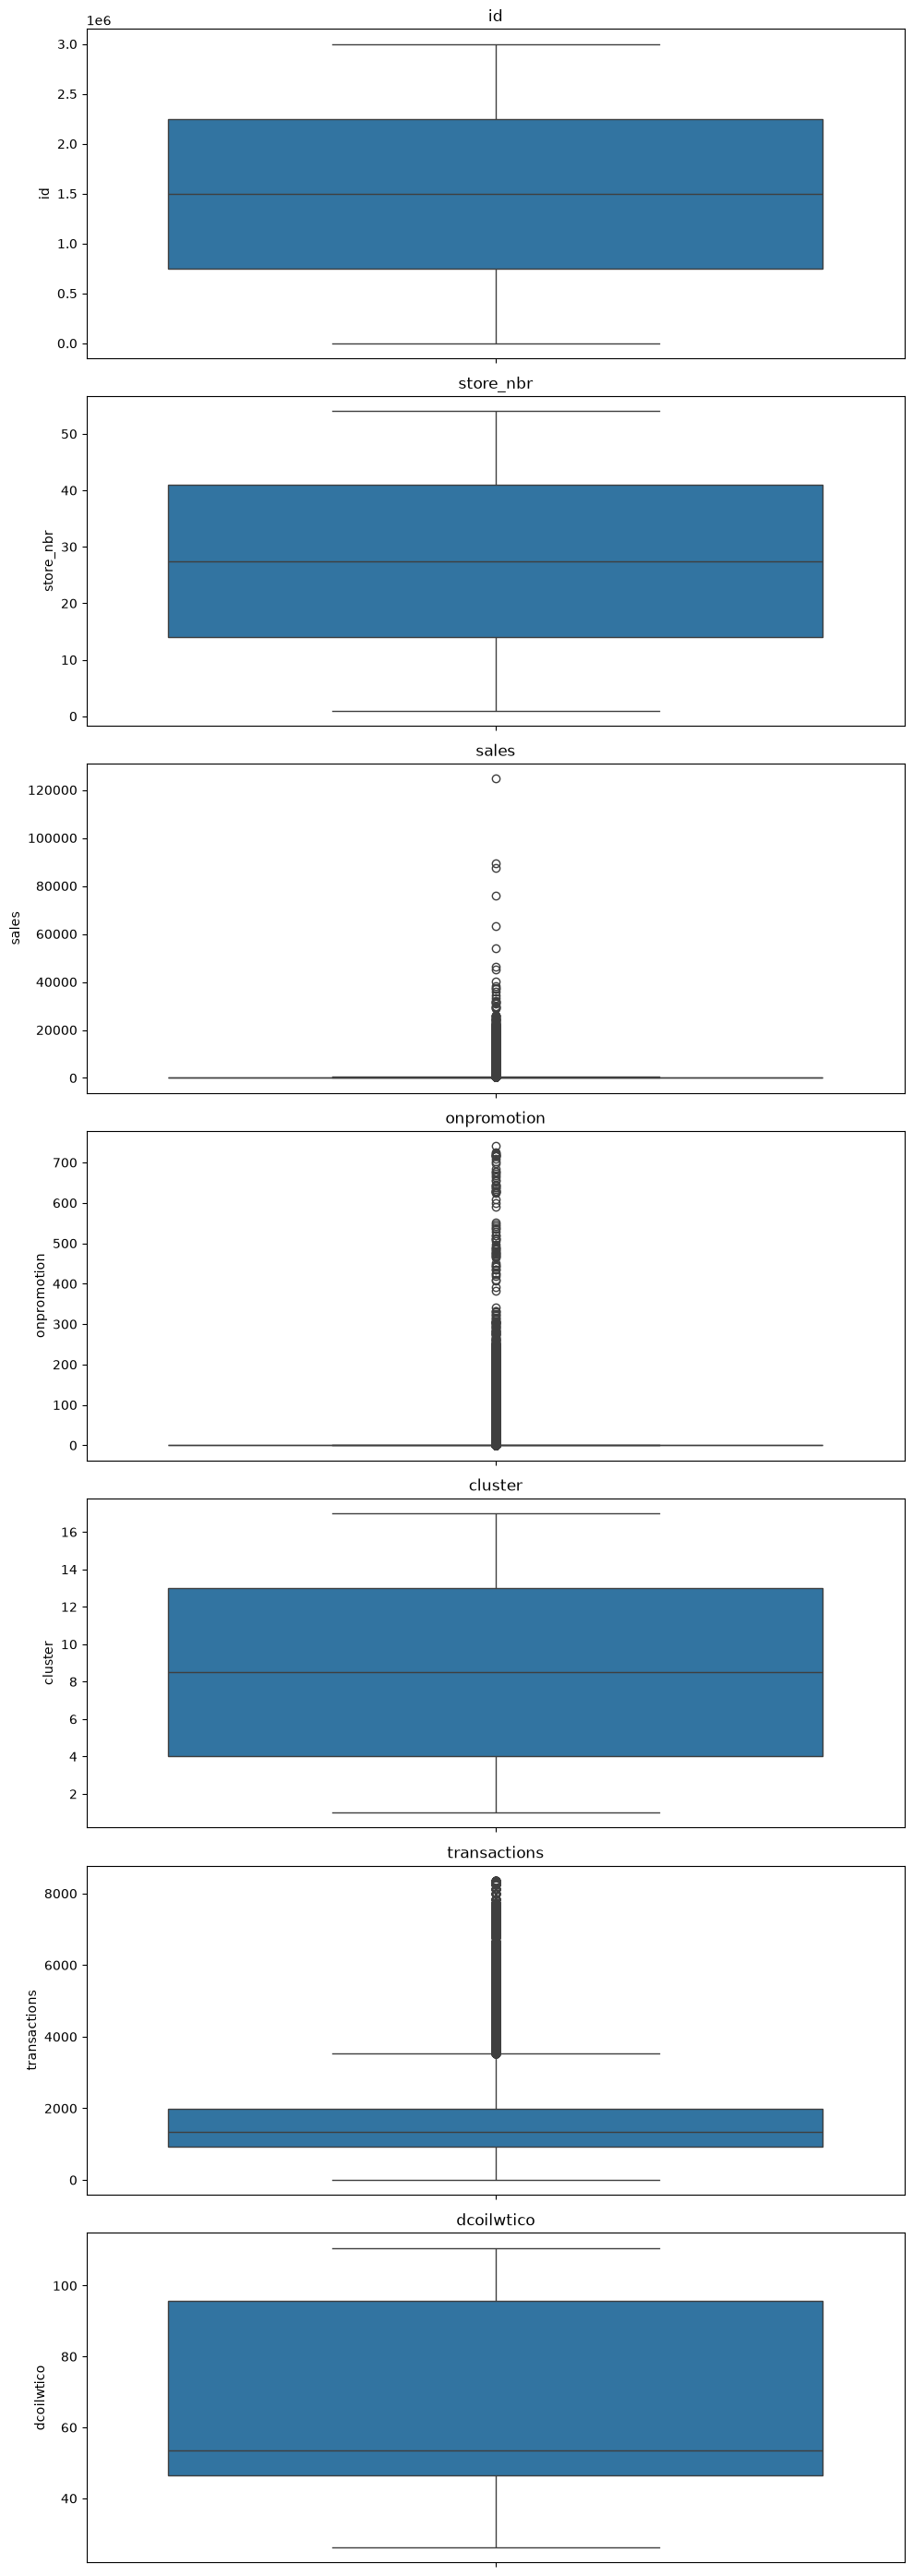

In [63]:
fig, axes = plt.subplots(len(numeric_columns), 1, figsize=(10, 4 * len(numeric_columns)))
for ax, column in zip(axes, numeric_columns):
    sns.boxplot(data=stores_sales, y=column, ax=ax)
    ax.set_title(column)
plt.tight_layout()